# TROPOMI data visualization with Python
This notebook demonstrates how to visualize TROPOMI data using Python. It includes steps for processing the data and creating visualizations. It is designed to be run in a Jupyter Notebook environment and allows for interactive exploration of the data.

In [1]:
# first we define our imports
import os
import sys
import cartopy
import datetime
import numpy as np
import xarray as xr
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

ERROR 1: PROJ: proj_create_from_database: Open of /n/home03/lestrada/micromamba/envs/imi_env/share/proj failed


## Section 1: Function Definitions
This section defines a few handy functions that are used to read and process the data from the original netcdf format.

Functions included are:
- `read_tropomi`: Reads the operational tropomi data from a netcdf file.
- `read_blended`: Reads the blended data from a netcdf file.
- `filter_tropomi`: Filters the TROPOMI data based on a specified date range and standard set of filters.
- `filter_blended`: Filters the blended data based on a specified date range and standard set of filters.
- `get_tropomi_data`: Retrieves TROPOMI (or blended TROPOMI) data for a specified file.
- `get_tropomi_file_paths`: Returns a list of file paths for TROPOMI data files based on a specified date range and product type.
- `get_df_and_ds`: Takes observation dictionaries and compiles them into an xarray dataset and pandas dataframe.


In [2]:
def read_tropomi(filename):
    """
    Read TROPOMI data and save important variables to dictionary.

    Arguments
        filename [str]  : TROPOMI netcdf data file to read

    Returns
        dat      [dict] : Dictionary of important variables from TROPOMI:
                            - CH4
                            - Latitude
                            - Longitude
                            - QA value
                            - UTC time
                            - Time (utc time reshaped for orbit)
                            - Averaging kernel
                            - SWIR albedo
                            - NIR albedo
                            - Blended albedo
                            - CH4 prior profile
                            - Dry air subcolumns
                            - Latitude bounds
                            - Longitude bounds
                            - Vertical pressure profile
    """

    # Initialize dictionary for TROPOMI data
    dat = {}

    # Catch read errors in any of the variables
    try:
        # Store methane, QA, lat, lon, and time
        with xr.open_dataset(filename, group="PRODUCT") as tropomi_data:
            dat["methane"] = tropomi_data["methane_mixing_ratio_bias_corrected"].values[
                0, :, :
            ]
            dat["qa_value"] = tropomi_data["qa_value"].values[0, :, :]
            dat["longitude"] = tropomi_data["longitude"].values[0, :, :]
            dat["latitude"] = tropomi_data["latitude"].values[0, :, :]

            utc_str = tropomi_data["time_utc"].values[0, :]
            utc_str = np.array([d.replace("Z", "") for d in utc_str]).astype(
                "datetime64[ns]"
            )
            dat["time"] = np.repeat(
                utc_str[:, np.newaxis], dat["methane"].shape[1], axis=1
            )

        # Store column averaging kernel, SWIR and NIR surface albedo
        with xr.open_dataset(
            filename, group="PRODUCT/SUPPORT_DATA/DETAILED_RESULTS"
        ) as tropomi_data:
            dat["column_AK"] = tropomi_data["column_averaging_kernel"].values[
                0, :, :, ::-1
            ]
            dat["swir_albedo"] = tropomi_data["surface_albedo_SWIR"].values[0, :, :]
            dat["nir_albedo"] = tropomi_data["surface_albedo_NIR"].values[0, :, :]
            dat["blended_albedo"] = 2.4 * dat["nir_albedo"] - 1.13 * dat["swir_albedo"]

        # Store methane prior profile, dry air subcolumns
        with xr.open_dataset(
            filename, group="PRODUCT/SUPPORT_DATA/INPUT_DATA"
        ) as tropomi_data:
            dat["methane_profile_apriori"] = tropomi_data[
                "methane_profile_apriori"
            ].values[
                0, :, :, ::-1
            ]  # mol m-2
            dat["dry_air_subcolumns"] = tropomi_data["dry_air_subcolumns"].values[
                0, :, :, ::-1
            ]  # mol m-2

            # Surface classification values of NaN will be filtered out
            # due to a low QA value. We can make sure by setting them to 5
            # and making sure nothing outside of [0,1,2,3] makes it through.
            sc = tropomi_data["surface_classification"].values[0, :, :]
            nan_mask = np.isnan(sc)
            sc_no_nans = np.nan_to_num(sc, nan=0)
            sc = (sc_no_nans.astype("uint8") & 0x03).astype(int)
            sc[nan_mask] = 5
            dat["surface_classification"] = sc

            # Also get pressure interval and surface pressure for use below
            pressure_interval = (
                tropomi_data["pressure_interval"].values[0, :, :] / 100
            )  # Pa -> hPa
            surface_pressure = (
                tropomi_data["surface_pressure"].values[0, :, :] / 100
            )  # Pa -> hPa

        # Store latitude and longitude bounds for pixels
        with xr.open_dataset(
            filename, group="PRODUCT/SUPPORT_DATA/GEOLOCATIONS"
        ) as tropomi_data:
            dat["longitude_bounds"] = tropomi_data["longitude_bounds"].values[
                0, :, :, :
            ]
            dat["latitude_bounds"] = tropomi_data["latitude_bounds"].values[0, :, :, :]

        # Store vertical pressure profile
        n1 = dat["methane"].shape[
            0
        ]  # length of along-track dimension (scanline) of retrieval field
        n2 = dat["methane"].shape[
            1
        ]  # length of across-track dimension (ground_pixel) of retrieval field
        pressures = np.full([n1, n2, 12 + 1], np.nan, dtype=np.float32)
        for i in range(12 + 1):
            pressures[:, :, i] = surface_pressure - i * pressure_interval
        dat["pressures"] = pressures

    # Return an error if any of the variables were not read correctly
    except Exception as e:
        print(f"Error opening {filename}: {e}")
        return None

    return dat


def read_blended(filename):
    """
    Read Blended TROPOMI+GOSAT data and save important variables to dictionary.
    Arguments
        filename [str]  : Blended TROPOMI+GOSAT netcdf data file to read
    Returns
        dat      [dict] : Dictionary of important variables from Blended TROPOMI+GOSAT:
                            - CH4
                            - Latitude
                            - Longitude
                            - Time (utc time reshaped for orbit)
                            - Averaging kernel
                            - SWIR albedo
                            - NIR albedo
                            - Blended albedo
                            - CH4 prior profile
                            - Dry air subcolumns
                            - Latitude bounds
                            - Longitude bounds
                            - Surface classification
                            - Chi-Square for SWIR
                            - Vertical pressure profile
    """
    assert (
        "BLND" in filename
    ), f"BLND not in filename {filename}, but a blended function is being used"

    try:
        # Initialize dictionary for Blended TROPOMI+GOSAT data
        dat = {}

        # Extract data from netCDF file to our dictionary
        with xr.open_dataset(filename) as blended_data:

            dat["methane"] = blended_data["methane_mixing_ratio_blended"].values[:]
            dat["longitude"] = blended_data["longitude"].values[:]
            dat["latitude"] = blended_data["latitude"].values[:]
            dat["column_AK"] = blended_data["column_averaging_kernel"].values[:, ::-1]
            dat["swir_albedo"] = blended_data["surface_albedo_SWIR"][:]
            dat["nir_albedo"] = blended_data["surface_albedo_NIR"].values[:]
            dat["blended_albedo"] = 2.4 * dat["nir_albedo"] - 1.13 * dat["swir_albedo"]
            dat["methane_profile_apriori"] = blended_data[
                "methane_profile_apriori"
            ].values[:, ::-1]
            dat["dry_air_subcolumns"] = blended_data["dry_air_subcolumns"].values[
                :, ::-1
            ]
            dat["longitude_bounds"] = blended_data["longitude_bounds"].values[:]
            dat["latitude_bounds"] = blended_data["latitude_bounds"].values[:]
            dat["surface_classification"] = (
                blended_data["surface_classification"].values[:].astype("uint8") & 0x03
            ).astype(int)
            dat["chi_square_SWIR"] = blended_data["chi_square_SWIR"].values[:]

            # Remove "Z" from time so that numpy doesn't throw a warning
            utc_str = blended_data["time_utc"].values[:]
            dat["time"] = np.array([d.replace("Z", "") for d in utc_str]).astype(
                "datetime64[ns]"
            )

            # Need to calculate the pressure for the 13 TROPOMI levels (12 layer edges)
            pressure_interval = (
                blended_data["pressure_interval"].values[:] / 100
            )  # Pa -> hPa
            surface_pressure = (
                blended_data["surface_pressure"].values[:] / 100
            )  # Pa -> hPa
            n = len(dat["methane"])
            pressures = np.full([n, 12 + 1], np.nan, dtype=np.float32)
            for i in range(12 + 1):
                pressures[:, i] = surface_pressure - i * pressure_interval
            dat["pressures"] = pressures

        # Add an axis here to mimic the (scanline, groundpixel) format of operational TROPOMI data
        # This is so the blended data will be compatible with the TROPOMI operators
        for key in dat.keys():
            dat[key] = np.expand_dims(dat[key], axis=0)

    except Exception as e:
        print(f"Error opening {filename}: {e}")
        return None

    return dat


def filter_tropomi(tropomi_data, xlim, ylim, startdate, enddate, use_water_obs=False):
    """
    Description:
        Filter out any data that does not meet the following
        criteria: We only consider data within lat/lon/time bounds,
        with QA > 0.5 and that don't cross the antimeridian.
        Also, we filter out pixels south of 60S and (optionally) over water.
    Returns:
        numpy array with satellite indices for filtered tropomi data.
    """
    valid_idx = (
        (tropomi_data["longitude"] > xlim[0])
        & (tropomi_data["longitude"] < xlim[1])
        & (tropomi_data["latitude"] > ylim[0])
        & (tropomi_data["latitude"] < ylim[1])
        & (tropomi_data["time"] >= startdate)
        & (tropomi_data["time"] <= enddate)
        & (tropomi_data["qa_value"] >= 0.5)
        & (tropomi_data["longitude_bounds"].ptp(axis=2) < 100)
        & (tropomi_data["latitude"] > -60)
    )

    if use_water_obs:
        return np.where(valid_idx)
    else:
        return np.where(valid_idx & (tropomi_data["surface_classification"] != 1))


def filter_blended(blended_data, xlim, ylim, startdate, enddate, use_water_obs=False):
    """
    Description:
        Filter out any data that does not meet the following
        criteria: We only consider data within lat/lon/time bounds,
        that don't cross the antimeridian, and we filter out all
        coastal pixels (surface classification 3) and inland water
        pixels with a poor fit (surface classifcation 2,
        SWIR chi-2 > 20000) (recommendation from Balasus et al. 2023).
        Also, we filter out pixels south of 60S and (optionally) over water.
    Returns:
        numpy array with satellite indices for filtered tropomi data.
    """

    valid_idx = (
        (blended_data["longitude"] > xlim[0])
        & (blended_data["longitude"] < xlim[1])
        & (blended_data["latitude"] > ylim[0])
        & (blended_data["latitude"] < ylim[1])
        & (blended_data["time"] >= startdate)
        & (blended_data["time"] <= enddate)
        & (blended_data["longitude_bounds"].ptp(axis=2) < 100)
        & ~(
            (blended_data["surface_classification"] == 3)
            | (
                (blended_data["surface_classification"] == 2)
                & (blended_data["chi_square_SWIR"][:] > 20000)
            )
        )
        & (blended_data["latitude"] > -60)
    )

    if use_water_obs:
        return np.where(valid_idx)
    else:
        return np.where(valid_idx & (blended_data["surface_classification"] != 1))


def get_TROPOMI_data(
    file_path, BlendedTROPOMI, xlim, ylim, startdate_np64, enddate_np64, use_water_obs
):
    """
    Returns a dict with the lat, lon, xch4, and albedo_swir observations
    extracted from the given tropomi file. Filters are applied to remove
    unsuitable observations
    Args:
        file_path : string
            path to the tropomi file
        BlendedTROPOMI : bool
            if True, use blended TROPOMI+GOSAT data
        xlim: list
            longitudinal bounds for region of interest
        ylim: list
            latitudinal bounds for region of interest
        startdate_np64: datetime64
            start date for time period of interest
        enddate_np64: datetime64
            end date for time period of interest
        use_water_obs: bool
            if True, use observations over water
    Returns:
         tropomi_data: dict
            dictionary of the extracted values
    """
    # tropomi data dictionary
    tropomi_data = {"lat": [], "lon": [], "xch4": [], "swir_albedo": [], "time": []}

    # Load the TROPOMI data
    assert isinstance(BlendedTROPOMI, bool), "BlendedTROPOMI is not a bool"
    if BlendedTROPOMI:
        TROPOMI = read_blended(file_path)
    else:
        TROPOMI = read_tropomi(file_path)
    if TROPOMI == None:
        print(f"Skipping {file_path} due to error")
        return TROPOMI

    if BlendedTROPOMI:
        # Only going to consider data within lat/lon/time bounds and without problematic coastal pixels
        sat_ind = filter_blended(
            TROPOMI, xlim, ylim, startdate_np64, enddate_np64, use_water_obs
        )
    else:
        # Only going to consider data within lat/lon/time bounds, with QA > 0.5, and with safe surface albedo values
        sat_ind = filter_tropomi(
            TROPOMI, xlim, ylim, startdate_np64, enddate_np64, use_water_obs
        )

    # Loop over observations and archive
    num_obs = len(sat_ind[0])
    for k in range(num_obs):
        lat_idx = sat_ind[0][k]
        lon_idx = sat_ind[1][k]
        tropomi_data["lat"].append(TROPOMI["latitude"][lat_idx, lon_idx])
        tropomi_data["lon"].append(TROPOMI["longitude"][lat_idx, lon_idx])
        tropomi_data["xch4"].append(TROPOMI["methane"][lat_idx, lon_idx])
        tropomi_data["swir_albedo"].append(TROPOMI["swir_albedo"][lat_idx, lon_idx])
        tropomi_data["time"].append(TROPOMI["time"][lat_idx, lon_idx])

    return tropomi_data


def get_tropomi_file_paths(start_date, end_date, dataset_dir, blendedTROPOMI):
    """
    Generate a list of TROPOMI file paths based on the start and end dates.
    """
    # modify file path based on whether blended TROPOMI data is used
    if blendedTROPOMI:
        dataset_dir = os.path.join(dataset_dir, "blended")
    else:
        dataset_dir = os.path.join(dataset_dir, "tropomi")

    # get list of all orbit file paths in the dataset directory
    orbit_files = [f for f in os.listdir(dataset_dir) if ".nc" in f]
    orbit_paths = [os.path.join(dataset_dir, f) for f in orbit_files]

    # filter out files outside the specified date range
    orbit_paths = [
        p
        for p in orbit_paths
        if int(p.split("____")[1][0:8]) >= int(start_date)
        and int(p.split("____")[1][0:8]) < int(end_date)
    ]
    # sort them so that they are in chronological order
    orbit_paths.sort()

    return orbit_paths


def get_df_and_ds(observation_dicts):
    """
    Convert a list of observation dictionaries into an xarray Dataset 
    and pandas Dataframe.

    Args:
        observation_dicts (list): List of dictionaries containing TROPOMI observations.

    Returns:
        xarray.Dataset: Dataset containing the observations.
        pandas.DataFrame: DataFrame containing the observations.
    """
    # define variables to be stored in the xarray Dataset
    lat = []
    lon = []
    xch4 = []
    albedo = []
    trtime = []

    # extract the relevant data from each observation dictionary
    for obs_dict in observation_dicts:
        lat.extend(obs_dict["lat"])
        lon.extend(obs_dict["lon"])
        xch4.extend(obs_dict["xch4"])
        albedo.extend(obs_dict["swir_albedo"])
        trtime.extend(obs_dict["time"])

    # assemble in dataframe
    df = pd.DataFrame()
    df["lat"] = lat
    df["lon"] = lon
    df["swir_albedo"] = albedo
    df["xch4"] = xch4
    df["time"] = trtime

    # simple averaging scheme to grid the XCH4 data at 0.1 x 0.1 resolution
    df["lat"] = np.round(df["lat"], 1)
    df["lon"] = np.round(df["lon"], 1)

    # count number of observations per grid cell
    counts = df.groupby(["lat", "lon"]).size().reset_index(name="observation_counts")

    # aggregate the data by latitude and longitude and use mean for numeric columns
    means = df.groupby(["lat", "lon"]).mean(numeric_only=True).reset_index()

    # merge counts into means dataframe
    means = pd.merge(means, counts, on=["lat", "lon"])

    # convert the DataFrame to an xarray Dataset
    ds = means.set_index(["lat", "lon"]).to_xarray()
    return ds, df

## Section 2: Define input parameters

In [3]:
# start and end dates with the format YYYYMMDD
start_date = "20210101"
end_date = "20210131"

# Domain of interest bounds in latitude and longitude
lon_bounds = [-130, -65]  # Longitudinal bounds
lat_bounds = [24, 55]  # Latitudinal bounds

# Boolean to indicate if we want to use blended TROPOMI+GOSAT 
# data or TROPOMI operational product
blendedTROPOMI = True

# Whether to use water observations or not
use_water_obs = False

# directory where TROPOMI files are stored
dataset_dir = "/n/holylfs05/LABS/jacob_lab/Everyone/imi/ch4"


## Section 3: Get the TROPOMI data and store it in memory
By applying the functions defined in Section 1

Below we create an xarray dataset and a pandas dataframe from the TROPOMI data files. xarray is a common package used to visualize geospatial data, while a pandas dataframe allows for more detailed analysis of individual observations and is often used for data manipulation and analysis in Python.

For details on xarray datasets, see the [xarray documentation](https://docs.xarray.dev/en/latest/user-guide/data-structures.html).

For details on pandas dataframes, see the [pandas documentation](https://pandas.pydata.org/docs/user_guide/dsintro.html).

In [4]:
# First we get the tropomi orbit paths for the date range of interest
orbit_paths = get_tropomi_file_paths(
    start_date, end_date, dataset_dir, blendedTROPOMI
)

# Read in and filter tropomi observations (uses parallel processing)
observation_dicts = Parallel(n_jobs=-1)(
    delayed(get_TROPOMI_data)(
        file_path,
        blendedTROPOMI,
        lon_bounds,
        lat_bounds,
        np.datetime64(datetime.datetime.strptime(start_date, "%Y%m%d")),
        np.datetime64(datetime.datetime.strptime(end_date, "%Y%m%d")),
        use_water_obs,
    )
    for file_path in orbit_paths
)

# Remove any problematic observation dicts (eg. corrupted data file)
observation_dicts = list(filter(None, observation_dicts))

# convert the list of observation dictionaries to an xarray Dataset (easier to plot)
obs_ds, obs_df = ds = get_df_and_ds(observation_dicts)

# preview the pandas dataframe
obs_df.head()

,lat,lon,swir_albedo,xch4,time
0,45.900002,-65.000000,0.045953,1874.011841,2021-01-01 16:13:49.836
1,45.900002,-65.099998,0.051758,1869.193237,2021-01-01 16:13:50.676
2,46.000000,-65.099998,0.063644,1858.840698,2021-01-01 16:13:51.516
3,46.000000,-65.099998,0.071287,1863.144287,2021-01-01 16:13:52.356
4,46.099998,-65.199997,0.057706,1872.459351,2021-01-01 16:13:53.196


In [ ]:
# show the xarray dataset

obs_ds

<xarray.Dataset> Size: 3MB
Dimensions:             (lat: 285, lon: 598)
Coordinates:
  * lat                 (lat) float32 1kB 24.0 24.1 24.2 24.3 ... 52.2 52.3 52.5
  * lon                 (lon) float32 2kB -127.5 -127.4 -127.3 ... -65.1 -65.0
Data variables:
    swir_albedo         (lat, lon) float32 682kB nan nan nan nan ... nan nan nan
    xch4                (lat, lon) float32 682kB nan nan nan nan ... nan nan nan
    observation_counts  (lat, lon) float64 1MB nan nan nan nan ... nan nan nan

## Section 4: Visualize the TROPOMI data
Make maps visualizing the aggregated TROPOMI data for the specified parameters

In [6]:
# simple function to find the dynamic range for colorbar 
# that uses +/- 25 ppb around the median value
dynamic_range = lambda vals: (
    np.round(np.nanmedian(vals) / 25.0) * 25 - 25,
    np.round(np.nanmedian(vals) / 25.0) * 25 + 25,
)

# load some cartopy features for adding ocean and land features to the map
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
countries_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_0_countries", "50m"
)

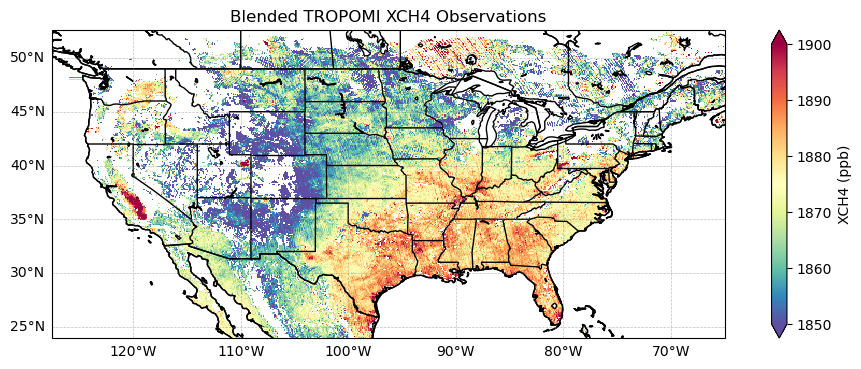

In [7]:
# plot the observations
fig, ax = plt.subplots(
    subplot_kw={"projection": cartopy.crs.PlateCarree()},
    figsize=(12, 4),
)
vmin, vmax = dynamic_range(obs_ds["xch4"].values)
obs_ds["xch4"].plot(
    ax=ax, cmap="Spectral_r", vmin=vmin, vmax=vmax, cbar_kwargs={"label": "XCH4 (ppb)"}
)
prefix = "" if not blendedTROPOMI else "Blended"
ax.set_title(f"{prefix} TROPOMI XCH4 Observations")

# Add coastlines and other features to make the map look nice
ax.add_feature(oceans_50m, edgecolor="black", facecolor="none")
ax.add_feature(lakes_50m, edgecolor="black", facecolor="none")
ax.add_feature(states_provinces_50m, edgecolor="black", facecolor="none")
ax.add_feature(countries_50m, edgecolor="black", facecolor="none")

# Add gridlines and labels
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

## Section 5: Challenge time!
This section is to practice your visualization skills and explore the data further. You can create your own visualizations and modify the code to suit your needs.

A few tasks to get you started:
- Try modifying the input parameters to look at different time ranges and locations
- The above visualization is averaged over the entire time range for each grid cell. Create a map that shows number of observations in each grid cell (Hint: look at the data variables of `obs_ds`).
- Plot the SWIR (Short Wave Infrared) albedo a map. Is there any correlation with albedo and the XCH4 values?
- Explore differences between the operational and blended TROPOMI data
- Explore differences between water observations and land observations -- are there any differences in the data quality or values?
- Create a time series showing the number of observations in a domain each month, then try weekly.
- Create a histogram of the TROPOMI data values.
- Create a time series of the TROPOMI data values for a specific grid cell.

Have fun exploring the data and feel free to ask us questions!

In [ ]:
# your code here
# add as many code blocks as you need